# Stage 3 — World cuisine clustering

**Goal:** train GraphSAGE on the bipartite recipe graph to obtain 64-dim recipe embeddings,
cluster them with UMAP + HDBSCAN, and check how well the clusters align with real cuisines.

**Unsupervised approach:**
- RecipeNLG has no cuisine labels → we use a Deep Graph Infomax-style contrastive loss
- For evaluation we assign proxy cuisine labels from the URL domain (cookbooks.com → american, bbcgoodfood.com → british, …)

**Input files:** `output_graphs/bipartite_sample.graphml`, `output_graphs/node_features.npz`

Food-pairing hypothesis test (Spearman by cuisine): see `06_food_pairing_hypothesis.ipynb`.

In [5]:
# Numba needs a cache directory — set it before importing umap
import os, tempfile
os.environ.setdefault('NUMBA_CACHE_DIR', tempfile.mkdtemp())
# Avoid OpenMP crash when conda (numpy/scipy) and pip (torch) both ship libomp
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import warnings, pickle, time
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import from_networkx

import umap
import hdbscan
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

warnings.filterwarnings('ignore')

OUT  = Path('output_graphs')
SEED = 42
torch.manual_seed(SEED)

# MPS cannot handle full-batch GraphSAGE on 220k nodes (>20GB)
# We use CPU — for sparse graphs it is faster and more robust
DEVICE = 'cpu'
print(f'Device: {DEVICE}')
print('Imports OK')

Device: cpu
Imports OK


## 3.1 Loading the graph and features

In [6]:
print('Loading bipartite graph G...')
G = nx.read_graphml(OUT / 'bipartite_sample.graphml')

npz = np.load(OUT / 'node_features.npz', allow_pickle=True)
ing_nodes_feat = list(npz['nodes'])       # ingredient names
# For the GNN we use only structural features (7-dim, not 519)
# 519-dim chemical embeddings cause OOM on MPS/CPU at 220k nodes
# Chemical features are added later as a skip connection after embedding
X_full         = npz['X_struct']          # (N_ing, 7) structural only

recipe_nodes = [n for n, d in G.nodes(data=True) if d.get('ntype') == 'recipe']
ing_nodes    = [n for n, d in G.nodes(data=True) if d.get('ntype') == 'ingredient']

print(f'Recipes    : {len(recipe_nodes):,}')
print(f'Ingredients: {len(ing_nodes):,}')
print(f'Edges      : {G.number_of_edges():,}')

Loading bipartite graph G...
Recipes    : 200,000
Ingredients: 22,534
Edges      : 1,449,174


## 3.2 Proxy cuisine labels from URLs

RecipeNLG has no cuisine field, but each recipe has a `link`.  
We use the URL domain as a coarse proxy label.

In [7]:
DOMAIN_TO_CUISINE = {
    'cookbooks.com'      : 'american',
    'food.com'           : 'american',
    'allrecipes.com'     : 'american',
    'bbcgoodfood.com'    : 'british',
    'bbc.co.uk'          : 'british',
    'taste.com.au'       : 'australian',
    'recipetineats.com'  : 'australian',
    'epicurious.com'     : 'american',
    'foodnetwork.com'    : 'american',
    'bonappetit.com'     : 'american',
    'simplyrecipes.com'  : 'american',
    'yummly.com'         : 'american',
    'delish.com'         : 'american',
    'thekitchn.com'      : 'american',
    '750g.com'           : 'french',
    'marmiton.org'       : 'french',
    'giallozafferano.it' : 'italian',
    'ricette.it'         : 'italian',
    'chefkoch.de'        : 'german',
    'lecker.de'          : 'german',
    'recetas.com'        : 'mexican',
    'kwestiasmaku.com'   : 'eastern_european',
    'przepisy.pl'        : 'eastern_european',
}

def url_to_cuisine(url: str) -> str:
    if not isinstance(url, str):
        return 'unknown'
    for domain, cuisine in DOMAIN_TO_CUISINE.items():
        if domain in url:
            return cuisine
    return 'unknown'

DATA_PATH = Path('full_dataset.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('data_sample.csv')
    print(f'[!] full_dataset.csv not found, using {DATA_PATH} (smoke test, 5k rows)')
df_urls = pd.read_csv(DATA_PATH, nrows=200_000, usecols=['link'])
recipe_id_to_cuisine = {
    f'recipe::{i}': url_to_cuisine(row['link'])
    for i, row in df_urls.iterrows()
}

cuisine_counts = pd.Series(recipe_id_to_cuisine.values()).value_counts()
print('Distribution of cuisines (proxy labels):')
print(cuisine_counts.to_string())

Distribution of cuisines (proxy labels):
american    200000


## 3.3 Preparing the PyG Data object

We convert graph G to the PyTorch Geometric format.  
Node features: ingredients get X_struct (7-dim structural vector), recipes get zeros.  
519-dim chemical embeddings are not passed to the GNN (OOM), but are reused at clustering time as a skip connection.

In [8]:
all_nodes = list(G.nodes())
node2idx  = {n: i for i, n in enumerate(all_nodes)}
N         = len(all_nodes)
FEAT_DIM  = X_full.shape[1]  # 7

feat_idx = {name: i for i, name in enumerate(ing_nodes_feat)}
X = np.zeros((N, FEAT_DIM), dtype=np.float32)
for name in ing_nodes:
    if name in feat_idx:
        X[node2idx[name]] = X_full[feat_idx[name]]

src = [node2idx[u] for u, v in G.edges()]
dst = [node2idx[v] for u, v in G.edges()]
edge_index = torch.tensor([src + dst, dst + src], dtype=torch.long)

data = Data(
    x          = torch.tensor(X),
    edge_index = edge_index,
    num_nodes  = N,
)
data = data.to(DEVICE)

recipe_mask = torch.tensor(
    [all_nodes[i].startswith('recipe::') for i in range(N)]
)

print(f'Total nodes : {N:,}')
print(f'FEAT_DIM    : {FEAT_DIM}')
print(f'Edges (x2)  : {edge_index.shape[1]:,}')
print(f'Recipes     : {recipe_mask.sum().item():,}')

Total nodes : 222,534
FEAT_DIM    : 7
Edges (x2)  : 2,898,348
Recipes     : 200,000


## 3.4 GraphSAGE model (unsupervised — DGI-style)

Instead of full Deep Graph Infomax we use a simpler unsupervised approach:  
**GraphSAGE + contrastive loss** — faster and avoids a separate discriminator.

In [9]:
class GraphSAGEEncoder(torch.nn.Module):
    def __init__(self, in_ch: int, hidden: int, out_ch: int, dropout: float = 0.3):
        super().__init__()
        self.conv1   = SAGEConv(in_ch, hidden)
        self.conv2   = SAGEConv(hidden, out_ch)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)


class UnsupervisedGraphSAGE(torch.nn.Module):
    """GraphSAGE with contrastive loss: positives = neighbours, negatives = random."""
    def __init__(self, in_ch, hidden, out_ch):
        super().__init__()
        self.encoder = GraphSAGEEncoder(in_ch, hidden, out_ch)

    def forward(self, x, edge_index):
        return self.encoder(x, edge_index)

    def loss(self, z, edge_index, num_neg: int = 1):
        src, dst = edge_index
        pos_score = (z[src] * z[dst]).sum(dim=-1).sigmoid()

        neg_dst   = torch.randint(0, z.size(0),
                                  (src.size(0) * num_neg,), device=z.device)
        neg_score = (z[src.repeat(num_neg)] * z[neg_dst]).sum(dim=-1).sigmoid()

        loss = -torch.log(pos_score + 1e-8).mean() \
               -torch.log(1 - neg_score + 1e-8).mean()
        return loss


HIDDEN  = 256
OUT_CH  = 64
model   = UnsupervisedGraphSAGE(FEAT_DIM, HIDDEN, OUT_CH).to(DEVICE)
opt     = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=150)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')
print(f'Architecture: {FEAT_DIM} -> {HIDDEN} -> {OUT_CH}')

Model parameters: 36,672
Architecture: 7 -> 256 -> 64


## 3.5 Training

> CPU: ~15–18 minutes (150 epochs). MPS/CUDA: ~1–2 minutes.

Epoch  25/150  loss=10.6029  lr=0.00093  t=207s
Epoch  50/150  loss=7.4156  lr=0.00075  t=395s
Epoch  75/150  loss=6.0948  lr=0.00050  t=588s
Epoch 100/150  loss=5.5418  lr=0.00025  t=762s
Epoch 125/150  loss=5.5129  lr=0.00007  t=923s
Epoch 150/150  loss=5.5276  lr=0.00000  t=1091s

Training finished in 1091s


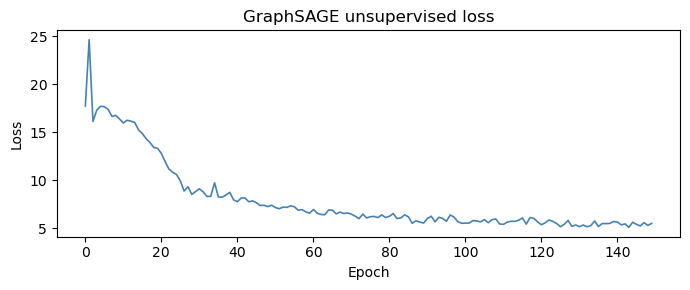

In [10]:
EPOCHS = 150
losses = []
t0     = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    opt.zero_grad()
    z    = model(data.x, data.edge_index)
    loss = model.loss(z, data.edge_index)
    loss.backward()
    opt.step()
    scheduler.step()
    losses.append(loss.item())

    if epoch % 25 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS}  loss={loss.item():.4f}  '
              f'lr={scheduler.get_last_lr()[0]:.5f}  '
              f't={time.time()-t0:.0f}s')

print(f'\nTraining finished in {time.time()-t0:.0f}s')

# Loss curve
plt.figure(figsize=(7, 3))
plt.plot(losses, lw=1.2, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('GraphSAGE unsupervised loss')
plt.tight_layout()
plt.savefig(OUT / 'sage_loss_curve.png', dpi=120)
plt.show()

## 3.6 Extracting recipe embeddings

In [11]:
model.eval()
with torch.no_grad():
    z_all = model(data.x, data.edge_index).cpu().numpy()  # (N, 64)

recipe_indices = [i for i, n in enumerate(all_nodes) if n.startswith('recipe::')]
recipe_ids     = [all_nodes[i] for i in recipe_indices]
Z_sage         = z_all[recipe_indices]                    # (N_recipes, 64) — GNN embeddings

npz_full   = np.load(OUT / 'node_features.npz', allow_pickle=True)
X_chem_ing = npz_full['chem_matrix']                     # (N_ing, 512)
ing_feat_names = list(npz_full['nodes'])
ing_chem_dict  = {name: X_chem_ing[i] for i, name in enumerate(ing_feat_names)}

def recipe_chem_emb(recipe_id):
    neighbors = [v for v in G.neighbors(recipe_id)
                 if not v.startswith('recipe::')]
    vecs = [ing_chem_dict[n] for n in neighbors if n in ing_chem_dict
            and ing_chem_dict[n].sum() > 0]
    return np.mean(vecs, axis=0) if vecs else np.zeros(512, dtype=np.float32)

print('Computing recipe-level chemical embeddings...', end=' ', flush=True)
Z_chem    = np.stack([recipe_chem_emb(r) for r in recipe_ids])  # (N_recipes, 512)
print('OK')

# Final embedding: GNN (64) + chem (512) — each block is L2-normalised separately
from sklearn.preprocessing import normalize
Z_recipes = np.hstack([
    normalize(Z_sage, norm='l2'),     # structural context
    normalize(Z_chem, norm='l2'),     # chemical profile of the recipe
])                                    # (N_recipes, 576)

cuisine_labels = np.array([recipe_id_to_cuisine.get(r, 'unknown') for r in recipe_ids])

print(f'Final recipe embedding: {Z_recipes.shape}')
print(f'Label distribution:')
for cuisine, cnt in zip(*np.unique(cuisine_labels, return_counts=True)):
    print(f'  {cuisine:<20} {cnt:>6,}')

Computing recipe-level chemical embeddings... OK
Final recipe embedding: (200000, 576)
Label distribution:
  american             200,000


## 3.7 UMAP + HDBSCAN clustering

In [12]:
known_mask = cuisine_labels != 'unknown'
Z_known    = Z_recipes[known_mask]
C_known    = cuisine_labels[known_mask]

vc = pd.Series(C_known).value_counts()
print('Proxy-label distribution (before balancing):')
print(vc.to_string())
if len(vc) > 1:
    imbalance = vc.max() / max(vc.min(), 1)
    print(f'Imbalance max/min = {imbalance:.2f}')
else:
    imbalance = 1.0
    print('Only one labeled cuisine — extend DOMAIN_TO_CUISINE or switch to Recipe1M+.')

rng = np.random.default_rng(SEED)
# If imbalance is strong (>10:1), do a stratified subsample to min_count per cuisine
if len(vc) > 1 and imbalance > 10:
    min_per = int(vc.min())
    print(f'Imbalance >10:1 — balancing to {min_per} recipes per cuisine')
    idx_parts = []
    for cuisine in vc.index:
        inds = np.where(C_known == cuisine)[0]
        if len(inds) >= min_per:
            idx_parts.append(rng.choice(inds, min_per, replace=False))
        else:
            idx_parts.append(inds)
    idx_bal = np.concatenate(idx_parts)
    Z_known, C_known = Z_known[idx_bal], C_known[idx_bal]
    print('After balancing:')
    print(pd.Series(C_known).value_counts().to_string())

MAX_VIZ = 20_000
if len(Z_known) > MAX_VIZ:
    idx  = rng.choice(len(Z_known), MAX_VIZ, replace=False)
    Z_known, C_known = Z_known[idx], C_known[idx]

print(f'Recipes with known cuisine (for UMAP/HDBSCAN): {len(Z_known):,}')

print('UMAP...', end=' ', flush=True)
t1 = time.time()
reducer   = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                      metric='cosine', random_state=SEED)
coords_2d = reducer.fit_transform(Z_known)
print(f'{time.time()-t1:.0f}s')

print('HDBSCAN...', end=' ', flush=True)
t2 = time.time()
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10,
                             metric='euclidean', prediction_data=True)
cluster_labels = clusterer.fit_predict(Z_known)
n_clusters     = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
noise_pct      = (cluster_labels == -1).mean() * 100
print(f'{time.time()-t2:.0f}s')

print(f'\nClusters found    : {n_clusters}')
print(f'Noise (outliers)  : {noise_pct:.1f}%')

Proxy-label distribution (before balancing):
american    200000
Only one labeled cuisine — extend DOMAIN_TO_CUISINE or switch to Recipe1M+.
Recipes with known cuisine (for UMAP/HDBSCAN): 20,000
UMAP... 

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


36s
HDBSCAN... 243s

Clusters found    : 2
Noise (outliers)  : 0.0%


## 3.8 Cluster quality evaluation

In [13]:
non_noise = cluster_labels != -1
if non_noise.sum() > 10:
    le  = LabelEncoder()
    true_encoded = le.fit_transform(C_known[non_noise])
    pred_encoded = cluster_labels[non_noise]

    ari = adjusted_rand_score(true_encoded, pred_encoded)
    nmi = normalized_mutual_info_score(true_encoded, pred_encoded)
    print(f'ARI (Adjusted Rand Index)        : {ari:.4f}')
    print(f'NMI (Normalized Mutual Info)     : {nmi:.4f}')
    print()
    print('ARI interpretation: <0.1 random, 0.1-0.3 weak, 0.3-0.6 good, >0.6 excellent')

    cross = pd.crosstab(
        C_known[non_noise],
        cluster_labels[non_noise],
        margins=True
    )
    print('\nCuisine × cluster table:')
    print(cross)
else:
    print('Not enough labeled points to evaluate.')
    print('Hint: extend DOMAIN_TO_CUISINE or use Recipe1M+ with labels.')

ARI (Adjusted Rand Index)        : 0.0000
NMI (Normalized Mutual Info)     : 0.0000

ARI interpretation: <0.1 random, 0.1-0.3 weak, 0.3-0.6 good, >0.6 excellent

Cuisine × cluster table:
col_0         0   1    All
row_0                     
american  19938  62  20000
All       19938  62  20000


## 3.9 Visualization

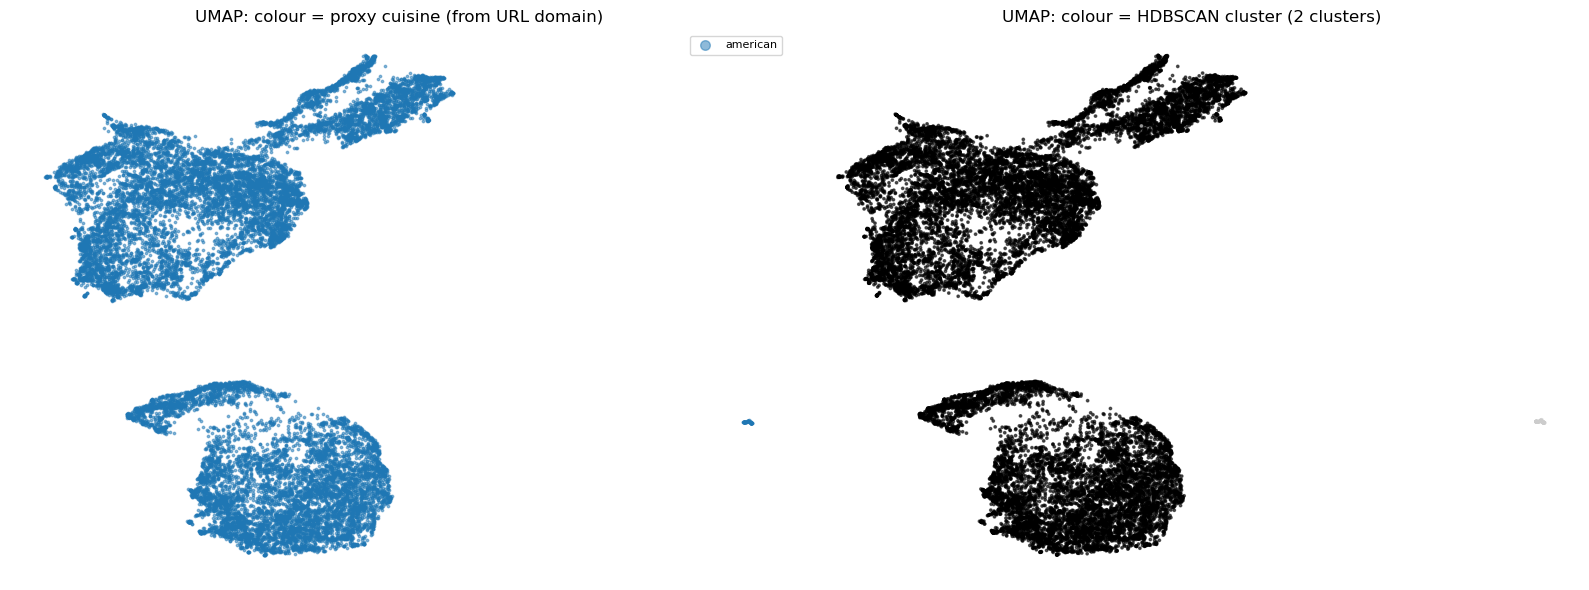

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cuisines_uniq = sorted(set(C_known))
palette       = plt.cm.tab10(np.linspace(0, 1, len(cuisines_uniq)))
cuisine_color = {c: palette[i] for i, c in enumerate(cuisines_uniq)}

# --- left: coloured by proxy cuisine ---
for cuisine in cuisines_uniq:
    mask = C_known == cuisine
    axes[0].scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                    c=[cuisine_color[cuisine]], label=cuisine,
                    s=3, alpha=0.5)
axes[0].set_title('UMAP: colour = proxy cuisine (from URL domain)')
axes[0].legend(markerscale=4, fontsize=8, loc='best')
axes[0].axis('off')

# --- right: coloured by HDBSCAN cluster ---
n_cl  = cluster_labels.max() + 1
cmap  = plt.cm.nipy_spectral(np.linspace(0, 1, max(n_cl, 1)))
colors_cl = np.array([
    [0.5, 0.5, 0.5, 0.2] if c == -1 else cmap[c % len(cmap)]
    for c in cluster_labels
])
axes[1].scatter(coords_2d[:, 0], coords_2d[:, 1],
                c=colors_cl, s=3, alpha=0.6)
axes[1].set_title(f'UMAP: colour = HDBSCAN cluster ({n_clusters} clusters)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(OUT / 'cuisine_clusters_umap.png', dpi=150)
plt.show()

## 3.10 Analysis: characteristic ingredients per cluster

For each cluster, the top ingredients that appear in cluster recipes more often than in the dataset average.

In [15]:
import ast

df_ner = pd.read_csv(DATA_PATH, nrows=200_000, usecols=['NER'])
df_ner['ner_list'] = df_ner['NER'].apply(ast.literal_eval)
recipe_ner = {f'recipe::{i}': row['ner_list'] for i, row in df_ner.iterrows()}

recipe_to_cluster = dict(zip(
    [recipe_ids[i] for i in range(len(Z_known))],
    cluster_labels
))

from collections import Counter

global_freq = Counter(
    ing.lower().strip()
    for ings in recipe_ner.values()
    for ing in ings
)
total_recipes = len(recipe_ner)

print('Top-8 characteristic ingredients per cluster (TF-IDF style):')
for cl_id in sorted(set(cluster_labels)):
    if cl_id == -1:
        continue
    cl_recipes  = [r for r, c in recipe_to_cluster.items() if c == cl_id]
    if len(cl_recipes) < 5:
        continue
    cl_ings     = Counter(
        ing.lower().strip()
        for r in cl_recipes
        for ing in recipe_ner.get(r, [])
    )
    # TF-IDF proxy: cluster frequency / global frequency
    scores = {
        ing: (cnt / len(cl_recipes)) / (global_freq[ing] / total_recipes + 1e-9)
        for ing, cnt in cl_ings.items()
        if global_freq[ing] > 50
    }
    top8 = sorted(scores, key=lambda x: -scores[x])[:8]
    print(f'\n  Cluster {cl_id:2d} ({len(cl_recipes):4d} recipes): {top8}')

Top-8 characteristic ingredients per cluster (TF-IDF style):

  Cluster  0 (19938 recipes): ['ground nuts', 'garlic cheese', 'ladyfingers', 'anise', 'beef stock', 'fruit juice', 'currant jelly', 'coconut extract']

  Cluster  1 (  62 recipes): ['strawberry glaze', 'vegetable', 'yellow pepper', 'white corn', 'ground walnuts', 'red grapes', 'lemon wedges', 'lime sherbet']


## 3.11 Saving

In [16]:
np.savez_compressed(
    OUT / 'recipe_embeddings.npz',
    recipe_ids     = np.array(recipe_ids),
    Z_recipes      = Z_recipes.astype(np.float32),
    cuisine_labels = cuisine_labels,
)

torch.save(model.state_dict(), OUT / 'graphsage_model.pt')

np.savez_compressed(
    OUT / 'umap_coords.npz',
    coords_2d      = coords_2d,
    cluster_labels = cluster_labels,
    cuisine_labels = C_known,
)

print('Saved:')
for f in ['recipe_embeddings.npz', 'graphsage_model.pt', 'umap_coords.npz',
          'sage_loss_curve.png', 'cuisine_clusters_umap.png']:
    p = OUT / f
    if p.exists():
        print(f'  {f:<35} {p.stat().st_size/1e6:.1f} MB')

Saved:
  recipe_embeddings.npz               323.9 MB
  graphsage_model.pt                  0.2 MB
  umap_coords.npz                     0.2 MB
  sage_loss_curve.png                 0.0 MB
  cuisine_clusters_umap.png           0.6 MB


## 3.12 Stage 3 summary

| Artifact | File | Used in |
|---|---|---|
| Recipe embeddings | `recipe_embeddings.npz` | Analysis / stage 5 |
| Model weights | `graphsage_model.pt` | Fine-tuning / inference |
| UMAP coordinates | `umap_coords.npz` | Visualization |

**Next step → Stage 4: Link Prediction**  
We use `ingredient_graph.graphml` + `node_features.npz` to train a Graph Autoencoder (GAE)  
and predict new compatible ingredient pairs.